In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif
import optuna
import lightgbm as lgb

In [86]:
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# 1. Read the data

In [87]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [88]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [89]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [90]:
df.shape

(7043, 21)

# 2. Data wrangling

In [91]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

In [92]:
print((df["TotalCharges"] == " ").sum())

11


In [93]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [94]:
median_charges = df["TotalCharges"].median()
df["TotalCharges"] = df["TotalCharges"].fillna(median_charges)

All 11 blank `TotalCharges` values belong to customers with `tenure` equal to 0, i.e. brand-new customers who have not been billed yet. Coercing to numeric turns the blanks into `NaN`, and filling with the overall median is a reasonable stand-in since these customers have no billing history to derive a better estimate from.

In [95]:
# A copy of the cleaned but unencoded data for EDA with readable category labels
df_raw = df.copy()

In [96]:
df["AvgMonthlyCharge"] = df["TotalCharges"] / (df["tenure"] + 1)
df["LongTerm"] = (df["tenure"] >= 24).astype(int)

In [97]:
df["gender"] = df["gender"].map({"Female": 0,
                                 "Male": 1})

df["Contract"] = df["Contract"].map({"Month-to-month": 0,
                                 "One year": 1,
                                 "Two year": 2})

yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

cols_to_dummy = ["MultipleLines", "InternetService", 
                 "OnlineSecurity", "OnlineBackup", 
                 "DeviceProtection", "TechSupport", 
                 "StreamingTV", "StreamingMovies",
                 "PaymentMethod"]

for col in yes_no_cols:
    df[col] = df[col].map({"No": 0, 
                           "Yes": 1})

dummy_cols = pd.get_dummies(
    df[cols_to_dummy],
    dtype=int
)

# Replace original categorical columns with dummies
df = pd.concat(
    [df.drop(columns=cols_to_dummy), dummy_cols],
    axis=1
)

df.dtypes

customerID                                  object
gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
Contract                                     int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
AvgMonthlyCharge                           float64
LongTerm                                     int64
MultipleLines_No                             int64
MultipleLines_No phone service               int64
MultipleLines_Yes                            int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No             

`Contract` and the yes/no columns are ordinal or binary, so they are mapped directly to integers instead of being one-hot-encoded. The remaining categorical columns are one-hot-encoded.

In [98]:
service_cols = [
    "OnlineSecurity_Yes",
    "OnlineBackup_Yes",
    "DeviceProtection_Yes",
    "TechSupport_Yes",
    "StreamingTV_Yes",
    "StreamingMovies_Yes"
]

df["NumServices"] = df[service_cols].sum(axis=1)

In [99]:
df.dtypes[df.dtypes == "object"]

customerID    object
dtype: object

Only `customerID` remains as text, which is an identifier and is dropped before modeling rather than encoded.

# 3. Exploratory Data Analysis

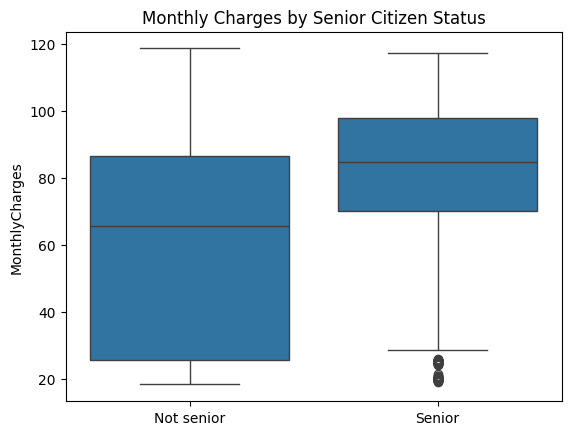

In [100]:
sns.boxplot(x="SeniorCitizen", y="MonthlyCharges", data=df_raw)
plt.title("Monthly Charges by Senior Citizen Status")
plt.xticks([0, 1], ["Not senior", "Senior"])
plt.xlabel("")
plt.show()

Senior citizens pay noticeably higher monthly charges on average, with a higher median and a tighter, more upper-shifted distribution than non-seniors.

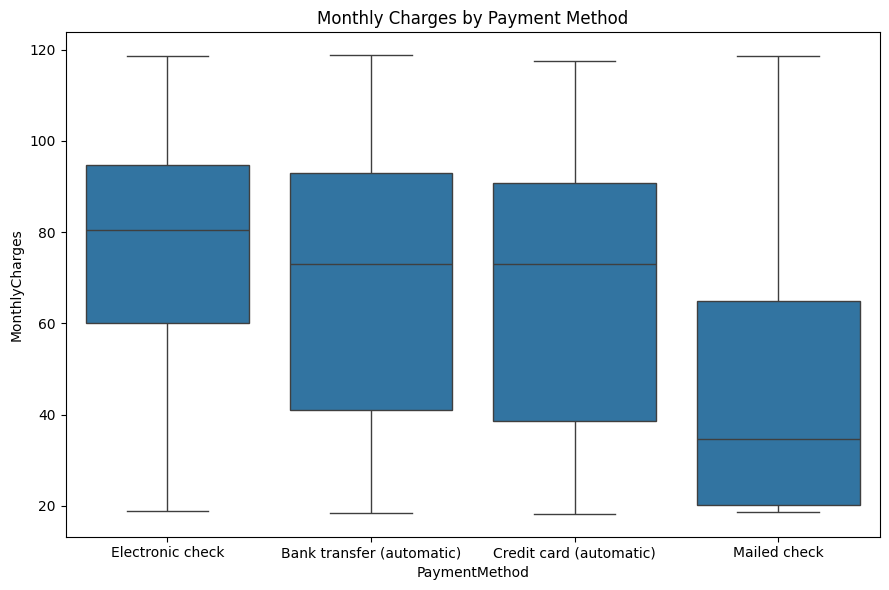

In [101]:
plt.figure(figsize=(9, 6))
order = df_raw.groupby("PaymentMethod")["MonthlyCharges"].median().sort_values(ascending=False).index
sns.boxplot(x="PaymentMethod", y="MonthlyCharges", data=df_raw, order=order)

plt.title("Monthly Charges by Payment Method")
plt.tight_layout()
plt.show()

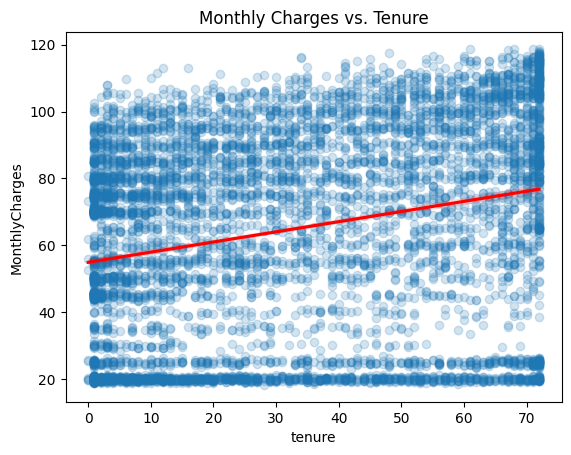

In [102]:
sns.regplot(x="tenure", y="MonthlyCharges", data=df_raw, scatter_kws={"alpha": 0.2}, line_kws={"color": "red"})
plt.title("Monthly Charges vs. Tenure")
plt.show()

There is only a weak positive trend between tenure and monthly charges: long-tenured customers skew slightly higher on average, but the spread at every tenure level is wide, with affordable and expensive monthly charge customers present for every tenure. Tenure looks like it will matter to churn mostly through accumulated loyalty and contract effects rather than through price alone.

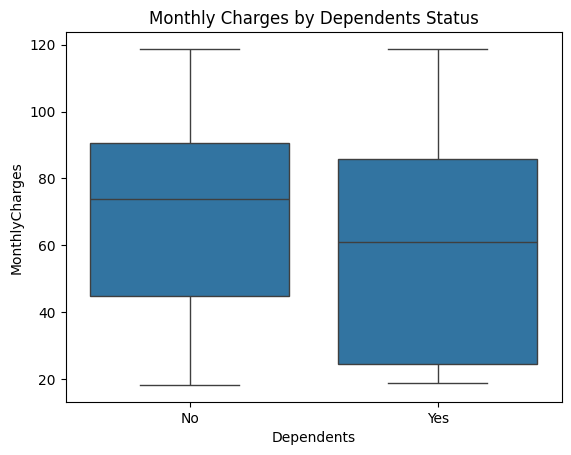

In [103]:
sns.boxplot(x="Dependents", y="MonthlyCharges", data=df_raw)
plt.title("Monthly Charges by Dependents Status")
plt.show()

<Axes: xlabel='Contract', ylabel='Churn'>

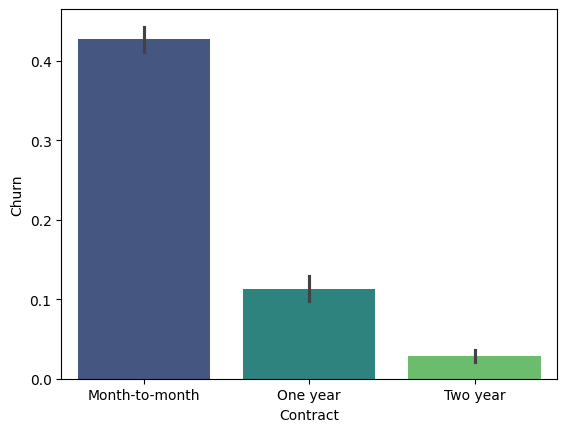

In [104]:
sns.barplot(
    x="Contract",
    y=df_raw["Churn"] == "Yes",
    data=df_raw,
    hue="Contract",
    palette="viridis"
)

In [105]:
pd.crosstab(
    df_raw["Contract"],
    df_raw["Churn"],
    normalize="index"
).mul(100).round(1)

Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


Churn drops sharply as contract length increases: 42.7% of month-to-month customers churn, versus 11.3% on one-year contracts and just 2.8% on two-year contracts. Contract length looks like the single strongest lever the insurance company has over churn, and the company may find it valuable to try to convert existing month-to-month contracts to one or two year contracts.

In [106]:
pd.crosstab(
    df_raw["InternetService"],
    df_raw["Churn"],
    normalize="index"
).mul(100).round(1)

Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4


In [107]:
pd.crosstab(
    df_raw["PaymentMethod"],
    df_raw["Churn"],
    normalize="index"
).mul(100).round(1)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.3,16.7
Credit card (automatic),84.8,15.2
Electronic check,54.7,45.3
Mailed check,80.9,19.1


Fiber optic customers churn at roughly twice the rate of DSL customers (41.9% vs. 19.0%), and customers paying by electronic check churn far more than any other payment method (45.3%, compared to 15.2-19.1% for the other three methods). This may reflect dissatisfaction with the fiber product itself.

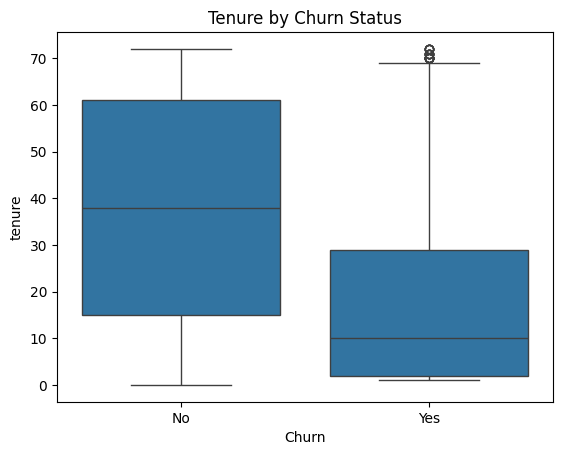

In [108]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df_raw
)
plt.title("Tenure by Churn Status")
plt.show()

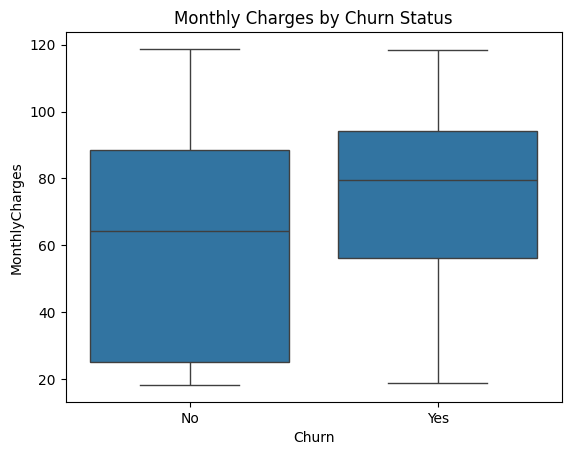

In [109]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df_raw
)
plt.title("Monthly Charges by Churn Status")
plt.show()

Churned customers have both shorter tenure (median ~10 months compared to ~38 months for retained customers) and higher monthly charges. This suggests that churn is concentrated among newer, higher-paying customers who haven't yet committed to a longer contract.

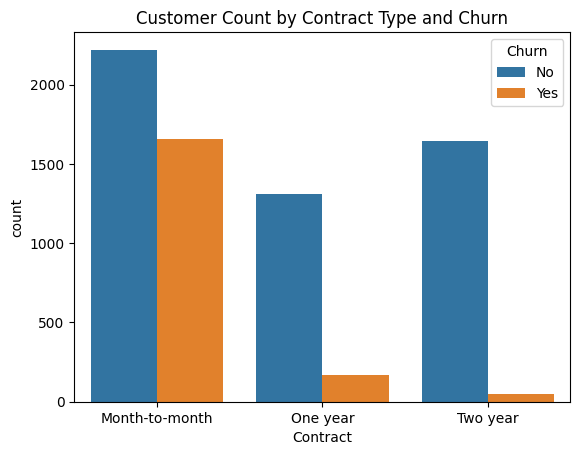

In [110]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df_raw
)
plt.title("Customer Count by Contract Type and Churn")
plt.show()

In [111]:
corr_target = (
    df.corr(numeric_only=True)["Churn"]
    .drop("Churn")
    .sort_values(ascending=False)
    .rename_axis("Feature")
)

corr_target

Feature
OnlineSecurity_No                          0.342637
TechSupport_No                             0.337281
InternetService_Fiber optic                0.308020
PaymentMethod_Electronic check             0.301919
OnlineBackup_No                            0.268005
DeviceProtection_No                        0.252481
MonthlyCharges                             0.193356
PaperlessBilling                           0.191825
SeniorCitizen                              0.150889
StreamingMovies_No                         0.130845
StreamingTV_No                             0.128916
StreamingTV_Yes                            0.063228
StreamingMovies_Yes                        0.061382
MultipleLines_Yes                          0.040102
AvgMonthlyCharge                           0.014873
PhoneService                               0.011942
gender                                    -0.008612
MultipleLines_No phone service            -0.011942
MultipleLines_No                          -0.032569
Devi

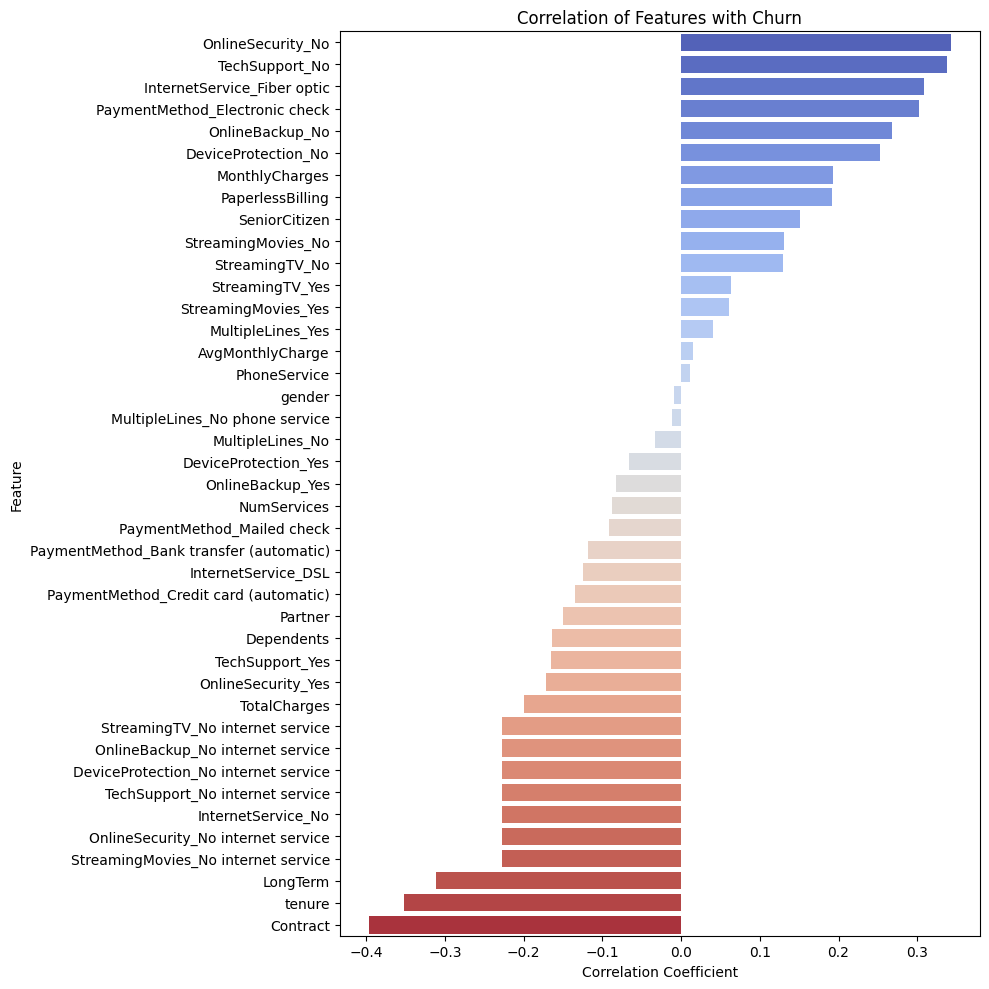

In [112]:
plt.figure(figsize=(10, 10))
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, palette="coolwarm", legend=False)
plt.title("Correlation of Features with Churn")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

`Contract`, `tenure`, and `LongTerm` show the strongest negative correlation with churn (longer customer relationships churn less). The lack of add-on services (`OnlineSecurity_No`, `TechSupport_No`) as well as  `InternetService_Fiber optic` and `PaymentMethod_Electronic check` show the strongest positive correlation.

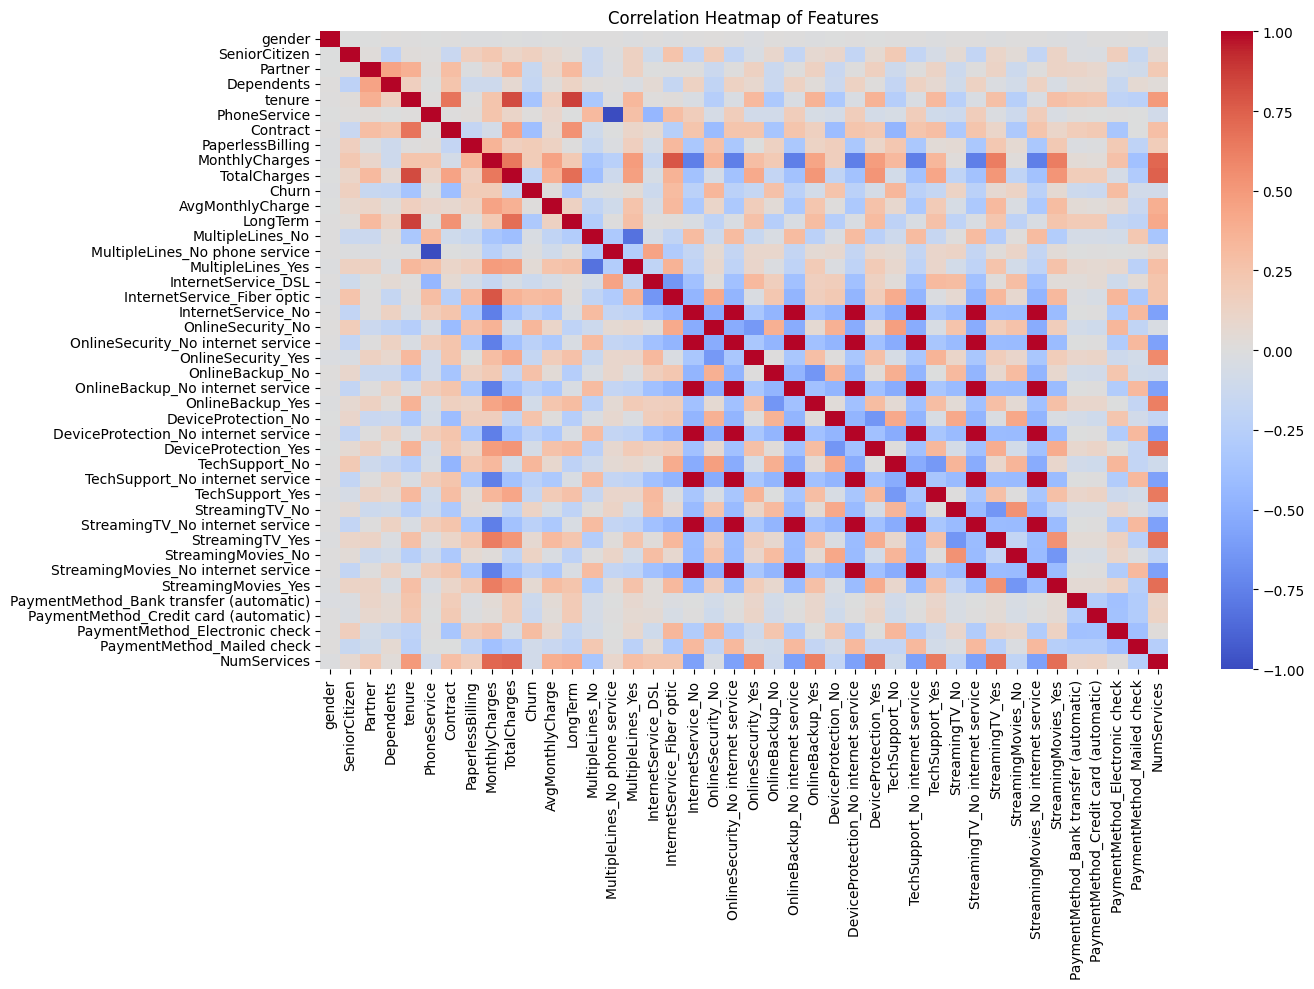

In [113]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()

# 4. Model development

In [114]:
# 4.1 Train/validation split

X = df.copy().drop(columns=["customerID"])
y = X.pop("Churn")

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [115]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=0)
mi_scores = pd.Series(mi_scores, index=X_train.columns, name="MI Score").sort_values(ascending=False)
mi_scores

Contract                                   0.102667
tenure                                     0.073209
OnlineSecurity_No                          0.067455
TechSupport_No                             0.064107
PaymentMethod_Electronic check             0.048173
InternetService_Fiber optic                0.048158
MonthlyCharges                             0.046138
LongTerm                                   0.043290
TotalCharges                               0.040737
AvgMonthlyCharge                           0.040589
DeviceProtection_No internet service       0.037731
StreamingTV_No internet service            0.036437
OnlineBackup_No internet service           0.033822
InternetService_No                         0.033429
DeviceProtection_No                        0.031261
StreamingMovies_No internet service        0.031130
PaperlessBilling                           0.028308
NumServices                                0.027188
OnlineSecurity_No internet service         0.023871
SeniorCitize

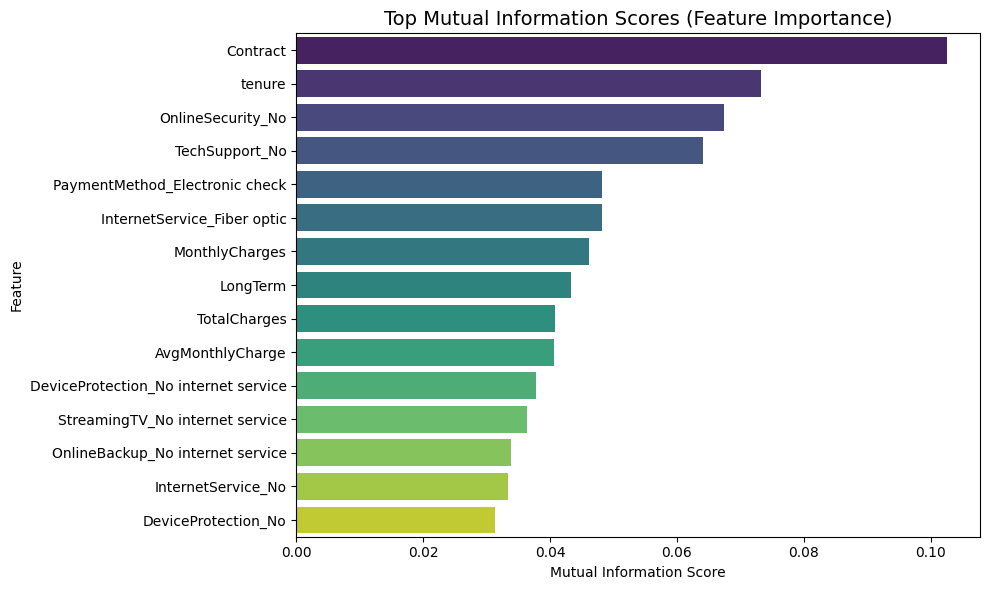

In [116]:
top_n = 15
plot_data = mi_scores.head(top_n)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=plot_data.values,
    y=plot_data.index,
    hue=plot_data.index,
    palette="viridis",
    legend=False
)

plt.title("Top Mutual Information Scores (Feature Importance)", fontsize=14)
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

`Contract`, `tenure` and the lack of add-on services carry the most mutual information about churn, consistent with the EDA above.

In [117]:
# 4.2 Optuna objective
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "objective": "binary",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "n_estimators": 400,
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }

    model = lgb.LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc", # "roc_auc", "accuracy", "f1"
        cv=CV,
        n_jobs=-1
    )

    return scores.mean()

In [118]:
# 4.3 Run study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"\nBest ROC AUC : {study.best_value:.5f}")
print("Best params:", study.best_params)

[I 2026-06-28 21:04:16,850] A new study created in memory with name: no-name-bdd20f5e-f8a4-4ce5-9d89-df6389837815
[I 2026-06-28 21:04:19,890] Trial 0 finished with value: 0.8369992252299678 and parameters: {'learning_rate': 0.10514231135028046, 'num_leaves': 103, 'max_depth': 3, 'subsample': 0.6957851658626149, 'colsample_bytree': 0.7903066750629452, 'min_child_samples': 90}. Best is trial 0 with value: 0.8369992252299678.
[I 2026-06-28 21:04:26,120] Trial 1 finished with value: 0.8337751741894304 and parameters: {'learning_rate': 0.015831410918921922, 'num_leaves': 119, 'max_depth': 11, 'subsample': 0.6196370996146192, 'colsample_bytree': 0.8327032448686524, 'min_child_samples': 19}. Best is trial 0 with value: 0.8369992252299678.
[I 2026-06-28 21:04:28,366] Trial 2 finished with value: 0.8473417018343335 and parameters: {'learning_rate': 0.026009079218561076, 'num_leaves': 88, 'max_depth': 3, 'subsample': 0.6693664748388072, 'colsample_bytree': 0.9937654526501689, 'min_child_samples'


Best ROC AUC : 0.85009
Best params: {'learning_rate': 0.010224012191717072, 'num_leaves': 138, 'max_depth': 4, 'subsample': 0.7781595410553717, 'colsample_bytree': 0.9216182327644685, 'min_child_samples': 22}


In [119]:
# 4.4 Final model with the best parameters and full training data
best_params = study.best_params.copy()
best_params.update({
    "objective": "binary",
    "n_estimators": 400,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
})

best_model = lgb.LGBMClassifier(**best_params)

roc_auc = cross_val_score(
        best_model,
        X_train,
        y_train,
        scoring="roc_auc", # "roc_auc", "accuracy", "f1"
        cv=CV,
        n_jobs=-1
    ).mean()

print(f"CV ROC AUC: {roc_auc:.5f}")

CV ROC AUC: 0.85009


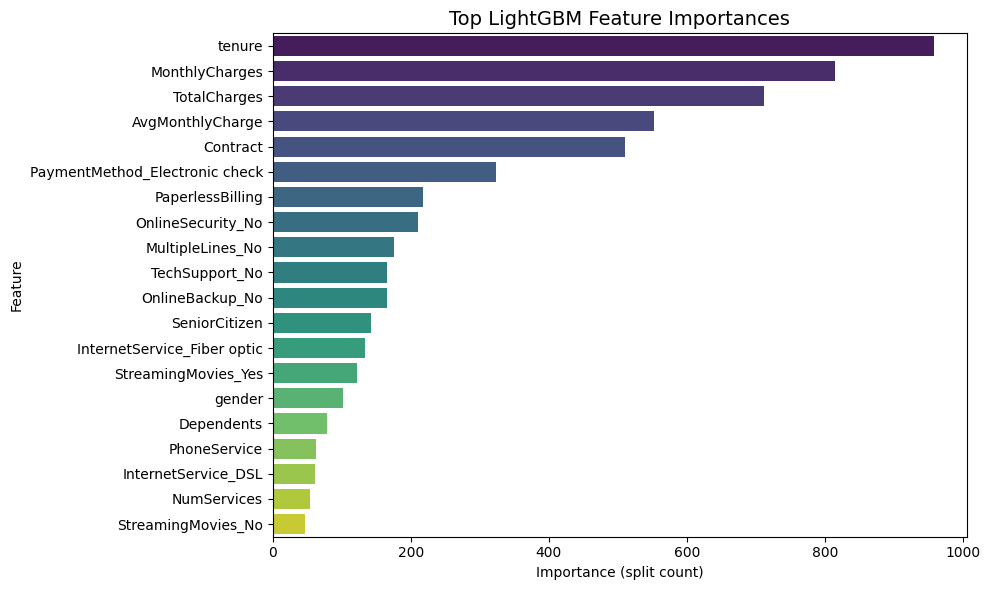

In [120]:
# 4.5 Feature importance
best_model.fit(X_train, y_train)

importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=importances.values,
    y=importances.index,
    hue=importances.index,
    palette="viridis",
    legend=False
)

plt.title("Top LightGBM Feature Importances", fontsize=14)
plt.xlabel("Importance (split count)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

`tenure`, `MonthlyCharges`, `TotalCharges`, and `Contract` dominate the tuned LightGBM model's split counts, broadly matching the mutual information ranking. Unlike the correlation analysis, the model also leans on the engineered `AvgMonthlyCharge` feature, suggesting it captures a nonlinear interaction between price and tenure that the raw columns don't expose on their own.

In [121]:
# 4.6 Generate predictions
predictions = best_model.predict(X_valid)
pred_proba = best_model.predict_proba(X_valid)[:, 1]

result = pd.DataFrame({
    "actual": y_valid,
    "predicted": predictions,
    "pred_proba": pred_proba
})

result["error"] = (result["actual"] != result["predicted"]).astype(int)

accuracy = accuracy_score(y_valid, predictions)
auc = roc_auc_score(y_valid, pred_proba)

print(f"Validation accuracy: {accuracy:.4f}")
print(f"Validation ROC AUC : {auc:.4f}")

Validation accuracy: 0.8077
Validation ROC AUC : 0.8459


In [122]:
print(classification_report(result["actual"], result["predicted"], target_names=["No churn", "Churn"]))

              precision    recall  f1-score   support

    No churn       0.84      0.91      0.87      1035
       Churn       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



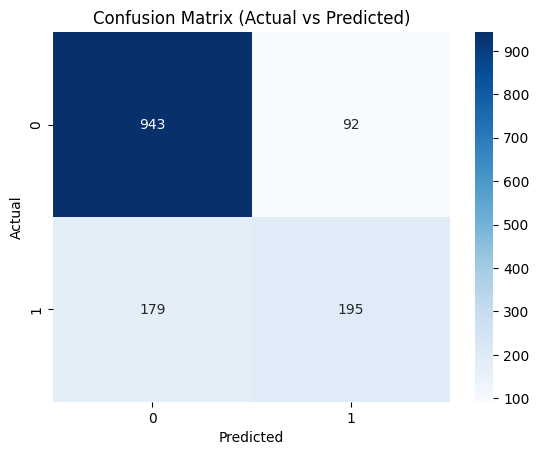

In [ ]:
cm = confusion_matrix(result["actual"], result["predicted"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Actual vs Predicted)")
plt.show()

Overall accuracy of about 80% looks solid, but the classification report shows the model is much better at recognizing customers who WILL NOT churn (90% recall) than those who WILL (51% recall). This is the expected effect of training on an imbalanced target (about 26.5% churn) with a default 0.5 decision threshold; in a real retention-targeting use case, the predicted probability itself (and a lower, business-chosen threshold) would matter more than the hard class label.

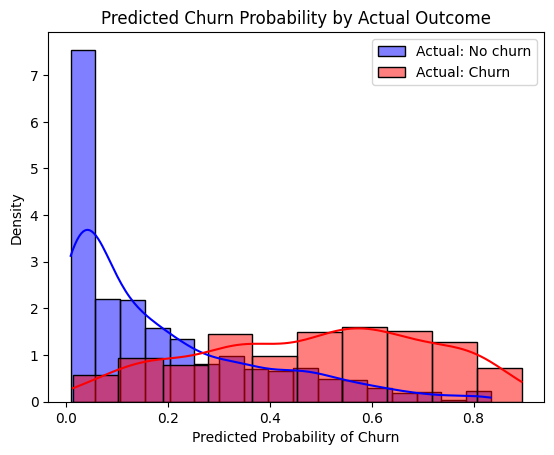

In [130]:
sns.histplot(result[result["actual"] == 0]["pred_proba"], color="blue", label="Actual: No churn", kde=True, stat="density", alpha=0.5)
sns.histplot(result[result["actual"] == 1]["pred_proba"], color="red", label="Actual: Churn", kde=True, stat="density", alpha=0.5)
plt.title("Predicted Churn Probability by Actual Outcome")
plt.xlabel("Predicted Probability of Churn")
plt.legend()
plt.show()

The two distributions separate well: customers who didn't churn are heavily weighted toward low predicted probabilities, while churners skew toward the middle and upper end of the scale. The overlap in the 0.3-0.6 range is where the default threshold struggles most, and where a business would have to decide how aggressively to flag borderline customers for retention outreach.

## 5. Summary of Findings

This analysis modeled customer churn for a telecom provider, combining data cleaning, exploratory analysis, and a tuned LightGBM classifier.

**Data quality** The raw data required modest cleanup before modeling: `TotalCharges` is stored as text and uses a blank string for 11 brand-new customers with zero tenure, which were coerced to numeric and filled with the median. Categorical service columns were one-hot-encoded, and engineered features (`AvgMonthlyCharge`, `LongTerm`, `NumServices`) were added to capture pricing and engagement patterns not present in any single raw column.

**What drives churn** Contract length is by far the dominant signal: churn falls from 42.7% on month-to-month contracts to 11.3% on one-year and 2.8% on two-year contracts, and `Contract` tops both the correlation and mutual information rankings. The lack of add-on services (`OnlineSecurity_No`, `TechSupport_No`) are also strong churn signals. Tenure and monthly charges move in the expected directions (longer-tenured customers churn less and higher-paying customers churn more). The tuned LightGBM model's feature importances broadly agree with this picture, while also surfacing the engineered `AvgMonthlyCharge` feature as informative, suggesting some of the signal is in how price and tenure interact.

**Model performance** After tuning hyperparameters with Optuna (5-fold CV, 50 trials, optimizing ROC AUC), the final LightGBM model reached a cross-validated ROC AUC of approximately 0.85. On the held-out validation set, the model reached around 80% accuracy and a similar ~0.85 ROC AUC, but recall is uneven across classes: Approximately 90% of non-churners are correctly identified versus only around 51% of churners, which is a direct consequence of training on an imbalanced target with a default 0.5 decision threshold. A follow-up iteration aimed at a real retention campaign would likely do better by working directly with `pred_proba` and a business-chosen threshold (or by addressing class imbalance directly, e.g. via class weighting) rather than relying on the default classification cutoff.